#  A/B Testing Assignment

##  Objective

- Determine if the ad campaign was successful

##  Experiment Setup

- Ad Group (Test): Users exposed to advertisements
- PSA Group (Control): Users shown a public service announcement (PSA) instead of ads

## Dataset Overview

- user_id: Unique identifier for each user
- test_group: 'ad' or 'psa' depending on exposure
- converted: True if the user made a purchase
- total_ads: Total number of ads the user saw
- most_ads_day: Day with highest ad exposure
- most_ads_hour: Hour with highest ad exposure

## Data Loading

In [2]:
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/hbb/Document/Dibimbing---DSDA/Assignment Day 27 - A:B Testing/marketing_AB.csv')
df.head(5)

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


## EDA

In [3]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

## Data Visualization

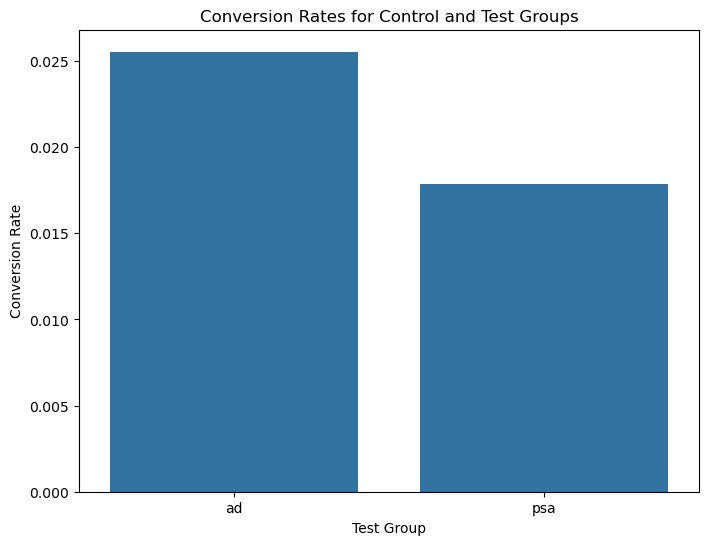

In [4]:
conversion_rates = df.groupby('test group')['converted'].mean().reset_index()
conversion_rates.columns = ['Test Group', 'Conversion Rate']
plt.figure(figsize = (8,6))
sns.barplot(data=conversion_rates, x='Test Group', y='Conversion Rate')
plt.title('Conversion Rates for Control and Test Groups')
plt.xlabel('Test Group')
plt.ylabel('Conversion Rate')
plt.show()

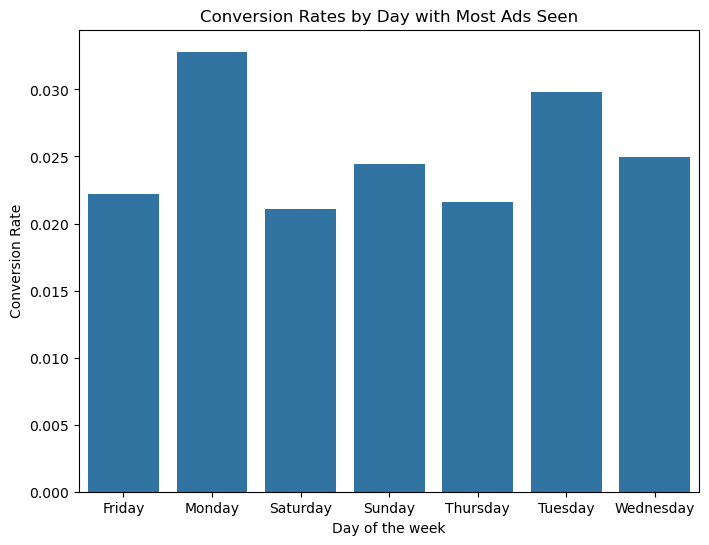

In [5]:
conversion_rates = df.groupby('most ads day')['converted'].mean().reset_index()
conversion_rates.columns = ['most ads day', 'Conversion Rate']
plt.figure(figsize = (8,6))
sns.barplot(data=conversion_rates, x='most ads day', y='Conversion Rate')
plt.title('Conversion Rates by Day with Most Ads Seen')
plt.xlabel('Day of the week')
plt.ylabel('Conversion Rate')
plt.show()

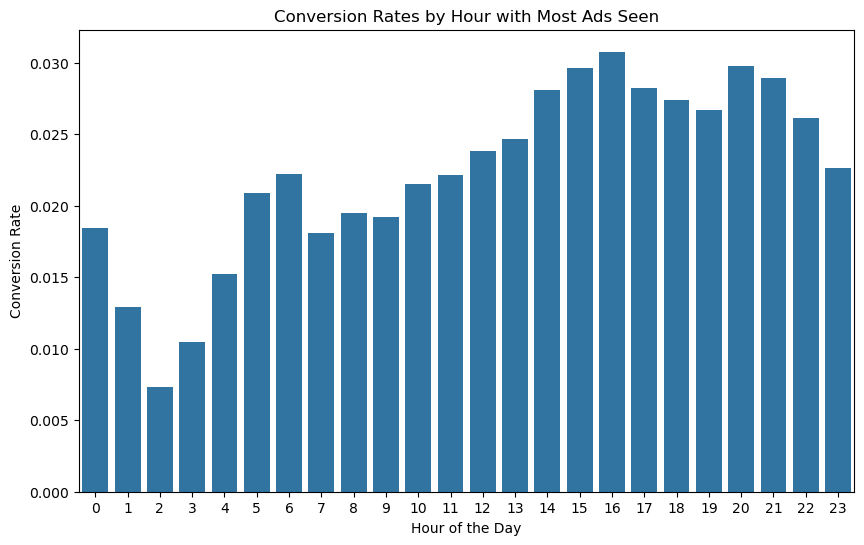

In [6]:
conversion_rates = df.groupby('most ads hour')['converted'].mean().reset_index()
conversion_rates.columns = ['most ads hour', 'Conversion Rate']
plt.figure(figsize = (10,6))
sns.barplot(data=conversion_rates, x='most ads hour', y='Conversion Rate')
plt.title('Conversion Rates by Hour with Most Ads Seen')
plt.xlabel('Hour of the Day')
plt.ylabel('Conversion Rate')
plt.show()

/var/folders/1q/y9bbyxz522bd8ynv6y9yhwx00000gn/T/ipykernel_17393/1024158101.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ads_conversion_rate_bin = df_subset.groupby('total_ads_bin')['converted'].mean().reset_index()


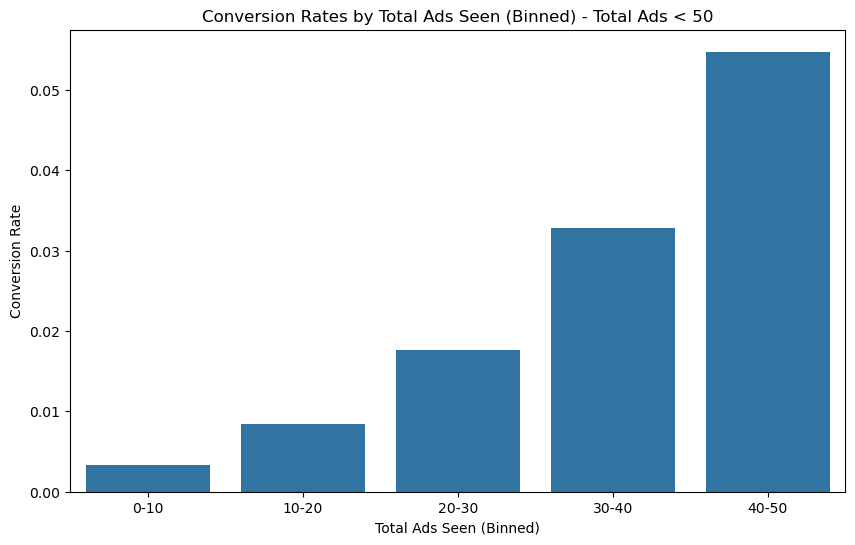

In [7]:
df_subset = df[df['total ads'] < 50].copy()
df_subset.loc[:, 'total_ads_bin'] = pd.cut(df_subset['total ads'], bins=[-1,10, 20, 30, 40, 50], 
                                           labels=['0-10', '10-20', '20-30', '30-40', '40-50'])

ads_conversion_rate_bin = df_subset.groupby('total_ads_bin')['converted'].mean().reset_index()
plt.figure(figsize = (10,6))
sns.barplot(data=ads_conversion_rate_bin, x='total_ads_bin', y='converted')
plt.title('Conversion Rates by Total Ads Seen (Binned) - Total Ads < 50')
plt.xlabel('Total Ads Seen (Binned)')
plt.ylabel('Conversion Rate')
plt.show()

## Statistical Testing

In [ ]:
df['test group'].value_counts(normalize=True) * 100

test group
ad     96.000007
psa     3.999993
Name: proportion, dtype: float64

##  Hypothesis

- **Null Hypothesis (H₀)**: There is no difference in conversion rates between the control (`no_ad`) and treatment (`ad`) groups.
- **Alternative Hypothesis (H₁)**: There is a significant difference in conversion rates between the two groups.


In [18]:
# Group by 'test group' and calculate conversion rates
conversion_rates = df.groupby('test group')['converted'].agg(['count', 'sum'])
conversion_rates['conversion_rate'] = conversion_rates['sum'] / conversion_rates['count']
conversion_rates


,count,sum,conversion_rate
test group,,,
ad,564577,14423,0.025547
psa,23524,420,0.017854


In [39]:
#Statistical Test (Two Proportion Z-Test)

control = df[df['test group'] == 'psa']
target = df[df['test group'] == 'ad']

successes = [control['converted'].sum(), target['converted'].sum()]
samples = [len(control), len(target)]

# Z-test
from statsmodels.stats.proportion import proportions_ztest
z_stat, p_val = proportions_ztest(successes, samples)

print(f"P-value: {p_val:.4f}")
print(f"Z-statistic: {z_stat:.4f}")


P-value: 0.0000
Z-statistic: -7.3701


### Conclusion

If the **p-value < 0.05**, we **reject the null hypothesis**:  
→ There is a statistically significant difference in conversion rates between the two groups.

Since the conversion rate for users shown ads is significantly higher than for those shown PSAs, and the result is statistically significant (p < 0.05), we recommend rolling out the ad-based strategy to more users to improve conversions.

## Normality Test (Total Ads)

The hypothesis testing for normality test:

$H_0$ : data is normally distributed

$H_1$ : data is not normally distributed

In [34]:
from scipy import stats

# Check if a metric (e.g., total ads) is normally distributed in each group
ads_psa = df[df['test group'] == 'psa']['total ads']
ads_ad = df[df['test group'] == 'ad']['total ads']

# Shapiro test
print("Shapiro test for PSA:", stats.shapiro(ads_psa.sample(5000, random_state=1)))
print("Shapiro test for AD:", stats.shapiro(ads_ad.sample(5000, random_state=1)))


Shapiro test for PSA: ShapiroResult(statistic=0.5433448400886145, pvalue=3.355381869827275e-78)
Shapiro test for AD: ShapiroResult(statistic=0.48705461544130735, pvalue=1.0560784803297746e-80)


In [31]:
def ad_normal_test(x):
  # Perform the Anderson-Darling test
  result = stats.anderson(x, dist='norm')

  # Interpretation
  for cv, sig in zip(result.critical_values[2:], result.significance_level[2:]):
    if result.statistic < cv:
        print(f"Fail to reject normality at {sig}% significance level")
    else:
        print(f"Reject normality at {sig}% significance level")

In [35]:
ad_normal_test(ads_psa)
ad_normal_test(ads_ad)

Reject normality at 5.0% significance level
Reject normality at 2.5% significance level
Reject normality at 1.0% significance level
Reject normality at 5.0% significance level
Reject normality at 2.5% significance level
Reject normality at 1.0% significance level


In [33]:
ad_normal_test(ads_ad)

Reject normality at 5.0% significance level
Reject normality at 2.5% significance level
Reject normality at 1.0% significance level


### Normality Test Conclusion

Both Shapiro-Wilk and Anderson-Darling tests indicate that the `total ads` data for both control (`psa`) and treatment (`ad`) groups are **not normally distributed**.

Therefore, we proceed with a **non-parametric test** (Mann-Whitney U Test) to compare the two groups.


## Mann Whitney Test

In [36]:
from scipy.stats import mannwhitneyu

u_stat, p_val = mannwhitneyu(ads_ad, ads_psa, alternative='greater')
print(f"U-Statistic: {u_stat:.4f}")
print(f"P-Value: {p_val:.4f}")

U-Statistic: 6808288222.0000
P-Value: 0.0000


In [37]:
# Perform the Mann-Whitney U test
stat, p_value = stats.mannwhitneyu(ads_ad, ads_psa, alternative='greater')

# Print results
print(f"P-value: {p_value}")
print(f"Mean of page views A: {ads_psa.mean():.2f}")
print(f"Mean of page views B: {ads_ad.mean():.2f}")

P-value: 2.3454554273602847e-11
Mean of page views A: 24.76
Mean of page views B: 24.82


### Mann-Whitney U Test Conclusion

- We tested whether users in the `ad` group saw significantly more ads than users in the `psa` group using the **Mann-Whitney U Test**, since the data was not normally distributed.

- **Result:**
  - P-value = 0.0
  - We reject the null hypothesis at the 5% significance level.

**Conclusion**:  
Users in the ad group were exposed to a significantly higher number of ads than those in the psa group, confirming that the treatment group received a different experience. This supports the integrity of our experimental design.


# Final Conclusion

The A/B test shows that the ad campaign was successful. Users who were shown advertisements (target group) had a significantly higher conversion rate than those shown public service announcements (control group), with a p-value of 0.0 from the Z-test. 

To confirm that the two groups experienced different levels of exposure, the number of ads shown was also compared. A Mann-Whitney U test revealed that the ad group received significantly more ads than the PSA group, validating the experimental setup.

### ✔ Recommendation:
The results demonstrate that the ad campaign had a positive and measurable impact on user conversions. It is recommended to continue or expand the use of this campaign strategy to increase engagement and performance.
